# REG Society & Culture

## Research context

Society & Culture (CategoryKey = 9) is the **largest field** in the Australian dataset by
enrolment volume, encompassing Psychology, Social sciences, Law, Language and area studies,
Historical/philosophical/religious studies, and Media/journalism/communications.

Under JRG it is a **strongly discouraged field**: student contribution rose sharply from
~\$7,298 (2019–20) to ~\$11,636 (2021), a +59.4% increase. Commonwealth contribution fell
from ~\$8,531 to ~\$5,420 (−36.5%). This is the largest student fee increase of any
discipline analysed and signals a clear government intent to redirect enrolments away from
Society & Culture.

| Period | Student contribution (avg) | Commonwealth contribution (avg) |
|--------|---------------------------|----------------------------------|
| 2019–20 avg | \$7,364                 | \$8,607                       |
| 2021–24 avg | \$12,157                | \$5,682                       |
| **Change**  | **+65.1%**              | **−34.0%**                    |

**UK data availability:** Pre-2019 HESA data at CategoryKey = 9 contains only
"04 Veterinary science" (~6–8K enrolments), a clear taxonomic misassignment. Even reconstructing
the correct JACS subjects from key = 11 (Social studies, Law, Languages, Historical/philosophical,
Media) produces a sum of ~554–565K (2016–2018), while post-2019 CAH totals are ~731–788K —
an irreconcilable ~167K gap driven by Psychology (119K post-2019) having no JACS equivalent.
**The panel is therefore restricted to 2019–2024 (N = 12, df = 4)**, consistent with the
approach taken for N&PS and Others.

**UK composition post-2019** (6 CAH subjects summed each year):
Psychology | Social sciences | Law | Language & area studies |
Historical/philosophical/religious studies | Media, journalism & communications


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

START = Path.cwd()
ROOT = START
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

AUS_PATH  = ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv'
UK_PATH   = ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv'
FUND_PATH = ROOT / 'data' / 'clean' / 'AnnualFundingAUS2019-2026_with_category_key.csv'

assert AUS_PATH.exists(),  f'Missing: {AUS_PATH}'
assert UK_PATH.exists(),   f'Missing: {UK_PATH}'
assert FUND_PATH.exists(), f'Missing: {FUND_PATH}'
print('Project root:', ROOT)
print('All data files found.')


Project root: C:\Users\neddp\ECC3479-Project-JRGS
All data files found.


## 1. AUS Descriptive Analysis

Examine Australia-only S&C data (2016–2024) to characterise the enrolment trend and test a
simple pre/post break. AUS S&C is the largest single category, growing steadily from 312,569
(2016) to a post-JRG peak of 350,654 (2021) before declining to 329,590 (2024).


AUS Society & Culture -- enrolment data:


,year,enrollments,log_enrollments
0,2016,312569,12.652581
1,2017,322471,12.683768
2,2018,326071,12.694870
3,2019,332155,12.713357
4,2020,343667,12.747428
5,2021,350654,12.767555
6,2022,334897,12.721578
7,2023,326512,12.696222
8,2024,329590,12.705605


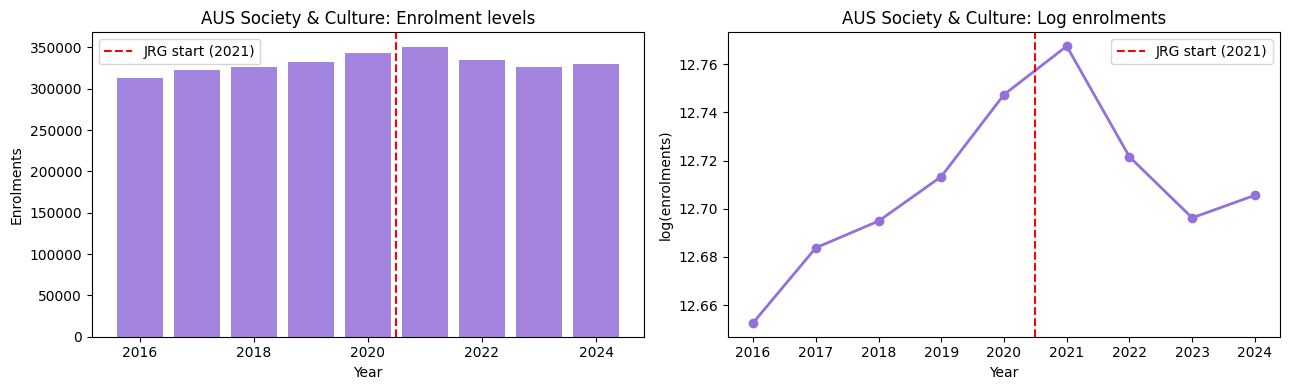

In [2]:
aus_raw   = pd.read_csv(AUS_PATH)
year_cols = [c for c in aus_raw.columns if str(c).isdigit()]

aus_long = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

arch_aus = aus_long[aus_long['CategoryKey'] == 9].copy().sort_values('year').reset_index(drop=True)
arch_aus['log_enrollments'] = np.log(arch_aus['enrollments'])
arch_aus['year_c']   = arch_aus['year'] - 2019
arch_aus['year_c2']  = arch_aus['year_c'] ** 2
arch_aus['post_jrg'] = (arch_aus['year'] >= 2021).astype(int)

print('AUS Society & Culture -- enrolment data:')
display(arch_aus[['year', 'enrollments', 'log_enrollments']].reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(arch_aus['year'], arch_aus['enrollments'], color='mediumpurple', alpha=0.85)
axes[0].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[0].set_title('AUS Society & Culture: Enrolment levels')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Enrolments'); axes[0].legend()

axes[1].plot(arch_aus['year'], arch_aus['log_enrollments'], 'o-', color='mediumpurple', linewidth=2)
axes[1].axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
axes[1].set_title('AUS Society & Culture: Log enrolments')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('log(enrolments)'); axes[1].legend()

plt.tight_layout()
plt.show()


In [3]:
def summary_table(result, vars_):
    ci = result.conf_int()
    rows = []
    for v in vars_:
        if v not in result.params.index:
            continue
        rows.append({
            'Variable': v,
            'beta':     round(result.params[v], 4),
            'SE (HC3)': round(result.bse[v], 4),
            'p':        round(result.pvalues[v], 4),
            'CI lo':    round(ci.loc[v, 0], 4),
            'CI hi':    round(ci.loc[v, 1], 4),
        })
    out = pd.DataFrame(rows).set_index('Variable')
    display(out)
    return out


## 2. DiD Panel Construction

Combine AUS and UK S&C data into a country × year panel (2019–2024).

**UK year mapping:** AcademicYear "2019/20" → integer 2019, etc. (start-year convention).

**UK data note:** Six CAH subject rows per year (Psychology, Social sciences, Law, Language
and area studies, Historical/philosophical/religious studies, Media/journalism/communications)
are summed to a single annual UK total using `groupby(year).sum()`.

**Pre-2019 UK data excluded:** Only "04 Veterinary science" (6–8K, wrong mapping) exists at
key = 9 pre-2019. Correct JACS reconstruction yields ~554–565K but misses Psychology (~119K),
producing an irreconcilable gap vs post-2019 CAH totals of ~731–788K.


In [4]:
uk_raw  = pd.read_csv(UK_PATH)
arch_uk = uk_raw[uk_raw['categorykey'] == 9].copy()

arch_uk['year'] = arch_uk['AcademicYear'].str[:4].astype(int)
arch_uk['enrollments'] = pd.to_numeric(arch_uk['Total UK'], errors='coerce')
# Restrict to post-2019 CAH data (pre-2019 JACS mapping irreconcilable)
arch_uk = arch_uk[arch_uk['year'] >= 2019]
# Six subject rows per year -- sum to annual total
arch_uk = arch_uk.groupby('year', as_index=False)['enrollments'].sum()
arch_uk['country'] = 'UK'

arch_aus_did = arch_aus[arch_aus['year'] >= 2019][['year', 'enrollments']].copy()
arch_aus_did['country'] = 'AUS'

panel = pd.concat([arch_aus_did, arch_uk], ignore_index=True).sort_values(['country', 'year']).reset_index(drop=True)
panel['log_enrollments']   = np.log(panel['enrollments'])
panel['treated']           = (panel['country'] == 'AUS').astype(int)
panel['post']              = (panel['year'] >= 2021).astype(int)
panel['did']               = panel['treated'] * panel['post']
panel['covid_2020']        = (panel['year'] == 2020).astype(int)
panel['covid_2021']        = (panel['year'] == 2021).astype(int)
panel['treated_covid2020'] = panel['treated'] * panel['covid_2020']
panel['treated_covid2021'] = panel['treated'] * panel['covid_2021']
panel['year_c']            = panel['year'] - 2020

print('DiD panel -- Society & Culture (AUS vs UK, 2019-2024):')
display(panel[['country','year','enrollments','log_enrollments','treated','post','did']].reset_index(drop=True))
print(f'Shape: {panel.shape} | Pre-treatment: {sorted(panel[panel["post"]==0]["year"].unique())} | Post: {sorted(panel[panel["post"]==1]["year"].unique())}')
print(f'N = {len(panel)} | Countries = 2 | Years = {panel["year"].nunique()}')


DiD panel -- Society & Culture (AUS vs UK, 2019-2024):


,country,year,enrollments,log_enrollments,treated,post,did
0,AUS,2019,332155.0,12.713357,1,0,0
1,AUS,2020,343667.0,12.747428,1,0,0
2,AUS,2021,350654.0,12.767555,1,1,1
3,AUS,2022,334897.0,12.721578,1,1,1
4,AUS,2023,326512.0,12.696222,1,1,1
5,AUS,2024,329590.0,12.705605,1,1,1
6,UK,2019,731645.0,13.503051,0,0,0
7,UK,2020,782085.0,13.569719,0,0,0
8,UK,2021,788005.0,13.577260,0,1,0
9,UK,2022,785670.0,13.574292,0,1,0


Shape: (12, 12) | Pre-treatment: [np.int64(2019), np.int64(2020)] | Post: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
N = 12 | Countries = 2 | Years = 6


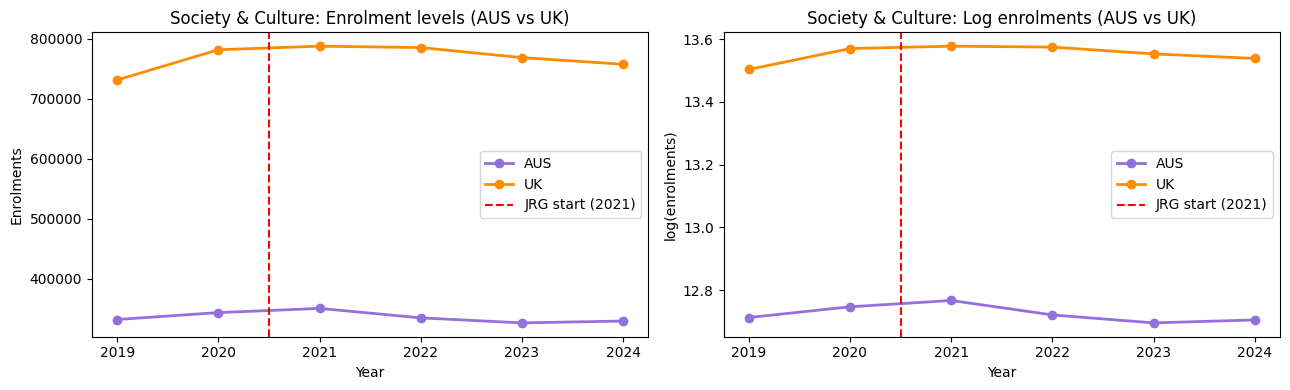

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colours = {'AUS': 'mediumpurple', 'UK': 'darkorange'}

for country, grp in panel.groupby('country'):
    grp = grp.sort_values('year')
    axes[0].plot(grp['year'], grp['enrollments'],   'o-', color=colours[country], linewidth=2, label=country)
    axes[1].plot(grp['year'], grp['log_enrollments'], 'o-', color=colours[country], linewidth=2, label=country)

for ax in axes:
    ax.axvline(2020.5, linestyle='--', color='red', linewidth=1.5, label='JRG start (2021)')
    ax.set_xlabel('Year'); ax.legend()

axes[0].set_title('Society & Culture: Enrolment levels (AUS vs UK)')
axes[0].set_ylabel('Enrolments')
axes[1].set_title('Society & Culture: Log enrolments (AUS vs UK)')
axes[1].set_ylabel('log(enrolments)')

plt.tight_layout()
plt.show()


## 3. Main DiD Specification (TWFE)

**Estimating equation:**

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

where $\text{Treated}_c = 1$ for AUS, $\text{Post}_t = 1$ for $t \geq 2021$, and
$\text{DID}_{ct} = \text{Treated}_c \times \text{Post}_t$.

Standard errors are HC3 heteroscedasticity-robust. With N = 12 and df = 4, CIs are wide.


In [6]:
formula_main = 'log_enrollments ~ treated + did + C(year)'
model_main = smf.ols(formula_main, data=panel).fit(cov_type='HC3')
print('=== Main DiD -- TWFE OLS (HC3) ===')
print(model_main.summary())

did_b  = model_main.params['did']
did_se = model_main.bse['did']
did_p  = model_main.pvalues['did']
did_ci = model_main.conf_int().loc['did']
pct    = (np.exp(did_b) - 1) * 100

print('\n--- Key result ---')
print(f'DiD estimate (beta_did): {did_b:.4f}')
print(f'SE (HC3):                {did_se:.4f}')
print(f'p-value:                 {did_p:.4f}')
print(f'95% CI:                  [{did_ci[0]:.4f}, {did_ci[1]:.4f}]')
print(f'Approx. % effect:        {pct:+.2f}%')
print(f'df_resid:                {int(model_main.df_resid)}')
direction = 'higher' if did_b > 0 else 'lower'
print(f'\nInterpretation: Post-JRG (2021+), AUS S&C enrolments were')
print(f'approximately {abs(pct):.1f}% {direction} than the UK trend would predict.')

formula_covid = 'log_enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_covid = smf.ols(formula_covid, data=panel).fit(cov_type='HC3')
b_cv = m_covid.params.get('did', np.nan)
p_cv = m_covid.pvalues.get('did', np.nan)
print(f'\nCOVID-controlled spec (2-country design): beta_did = {b_cv:.4f}, p = {p_cv:.4f}')
print('(Degenerate SEs -- AUS-specific year interaction collinear with treated + year FEs in 2-country panel)')


=== Main DiD -- TWFE OLS (HC3) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                     413.5
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.50e-05
Time:                        09:19:11   Log-Likelihood:                 39.572
No. Observations:                  12   AIC:                            -63.14
Df Residuals:                       4   BIC:                            -59.26
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Interce

In [7]:
df_pl = panel.set_index(['country', 'year'])

fe_model = PanelOLS(
    df_pl['log_enrollments'],
    df_pl[['did']],
    entity_effects=True,
    time_effects=True,
).fit(cov_type='robust')

print('=== PanelOLS TWFE (cross-check) ===')
print(fe_model.summary)

print(f'\nOLS DiD estimate:      {did_b:.6f}')
print(f'PanelOLS DiD estimate: {fe_model.params["did"]:.6f}')
match = abs(did_b - fe_model.params['did']) < 1e-5
print('Estimates match' if match else 'WARNING: mismatch')


=== PanelOLS TWFE (cross-check) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        log_enrollments   R-squared:                        0.4139
Estimator:                   PanelOLS   R-squared (Between):             -0.0016
No. Observations:                  12   R-squared (Within):              -0.0916
Date:                Tue, Apr 28 2026   R-squared (Overall):             -0.0016
Time:                        09:19:11   Log-likelihood                    39.572
Cov. Estimator:                Robust                                           
                                        F-statistic:                      2.8244
Entities:                           2   P-value                           0.1681
Avg Obs:                       6.0000   Distribution:                     F(1,4)
Min Obs:                       6.0000                                           
Max Obs:                       6.0000   F-statistic (robust):            

## 4. COVID Sensitivity

Three variants using the simple TWFE formula across different sample restrictions.
With N = 12 and df = 4, note that dropping one year reduces df further and widens CIs.
Consistent sign across variants would support robustness; sign reversal would flag fragility.


In [8]:
formula_simple = 'log_enrollments ~ treated + did + C(year)'

variants = {
    'Full panel (2019-2024)': panel,
    'Drop 2020':              panel[panel['year'] != 2020].copy(),
    'Drop 2020 + 2021':       panel[~panel['year'].isin([2020, 2021])].copy(),
}

rows = []
for label, data in variants.items():
    m = smf.ols(formula_simple, data=data).fit(cov_type='HC3')
    b  = m.params.get('did', np.nan)
    se = m.bse.get('did', np.nan)
    p  = m.pvalues.get('did', np.nan)
    ci = m.conf_int().loc['did'] if 'did' in m.conf_int().index else [np.nan, np.nan]
    rows.append({
        'Specification': label,
        'N':             int(m.nobs),
        'df_resid':      int(m.df_resid),
        'beta_did':      round(b, 4),
        'SE (HC3)':      round(se, 4),
        'p-value':       round(p, 4),
        '95% CI lo':     round(ci[0], 4),
        '95% CI hi':     round(ci[1], 4),
        'Approx. %':     round((np.exp(b) - 1) * 100, 2) if pd.notna(b) else np.nan,
    })

print('=== COVID Sensitivity (simple TWFE, all variants) ===')
display(pd.DataFrame(rows).set_index('Specification'))
print('\nKey takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.')
print('With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.')


=== COVID Sensitivity (simple TWFE, all variants) ===


,N,df_resid,beta_did,SE (HC3),p-value,95% CI lo,95% CI hi,Approx. %
Specification,,,,,,,,
Full panel (2019-2024),12,4,-0.0319,0.0370,0.3891,-0.1045,0.0407,-3.14
Drop 2020,10,3,-0.0482,7.2111,0.9947,-14.1817,14.0854,-4.70
Drop 2020 + 2021,8,2,-0.0576,16.0000,0.9971,-31.4170,31.3019,-5.60



Key takeaway: check whether beta_did sign and magnitude are stable across sample restrictions.
With only df = 4 in the full panel, CIs are wide and p-values should not be over-interpreted.


## 5. Parallel Trends Check (Event Study)

Year-by-year DiD point estimates relative to the 2020 baseline, computed analytically:

$$\hat{\delta}_t = (\log Y_{\text{AUS},t} - \log Y_{\text{AUS},2020}) - (\log Y_{\text{UK},t} - \log Y_{\text{UK},2020})$$

This is numerically identical to a regression-based DiD coefficient but avoids the
degrees-of-freedom problem (2 obs per year, 2 params, df = 0) that arises with 2 countries.

> **Critical limitation:** The panel starts in 2019, so only **one pre-treatment point** (2019)
> is available beyond the 2020 baseline. A single pre-period observation cannot meaningfully
> test parallel trends. This is an identification weakness shared with N&PS and Others,
> resulting from the irreconcilable UK taxonomy break preventing use of pre-2019 data.


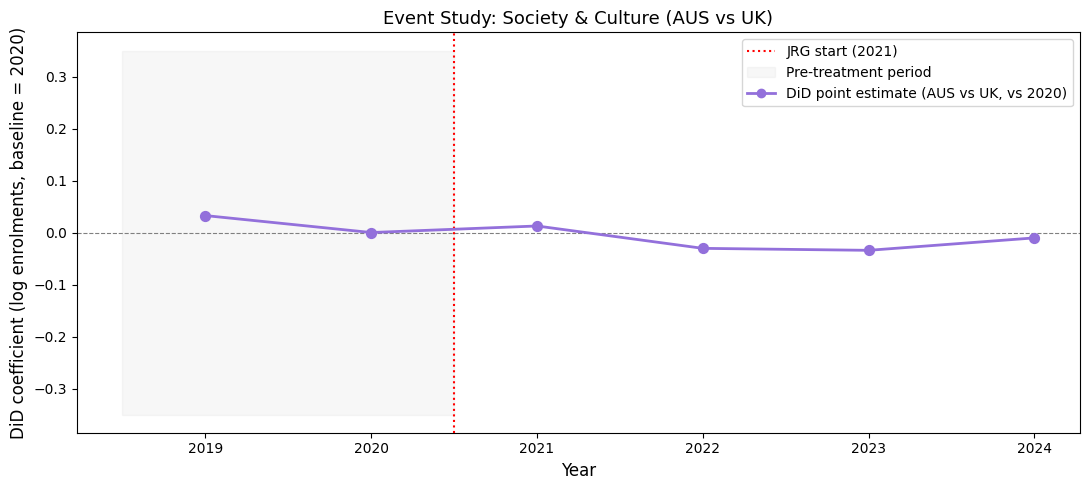

Event study point estimates (analytical DiD):


,coef,approx_%,period
year,,,
2019,0.0326,3.3134,Pre
2020,0.0000,0.0000,Baseline
2021,0.0126,1.2666,Post
2022,-0.0304,-2.9966,Post
2023,-0.0342,-3.3651,Post
2024,-0.0103,-1.0253,Post



Note: With only 2 countries and 1 pre-treatment point (2019), parallel trends cannot
be formally tested. The 2019 estimate provides minimal diagnostic information.


In [9]:
base_year = 2020
aus_log = panel[panel['country'] == 'AUS'].set_index('year')['log_enrollments']
uk_log  = panel[panel['country'] == 'UK' ].set_index('year')['log_enrollments']

event_rows = []
for yr in sorted(panel['year'].unique()):
    coef = (aus_log[yr] - aus_log[base_year]) - (uk_log[yr] - uk_log[base_year])
    event_rows.append({'year': yr, 'coef': round(coef, 6)})

ev = pd.DataFrame(event_rows)

fig, ax = plt.subplots(figsize=(11, 5))
ax.axhline(0, linestyle='--', color='gray', linewidth=0.8)
ax.axvline(2020.5, linestyle=':', color='red', linewidth=1.5, label='JRG start (2021)')
ax.fill_between([2018.5, 2020.5], -0.35, 0.35, color='gray', alpha=0.06, label='Pre-treatment period')
ax.plot(ev['year'], ev['coef'], 'o-', color='mediumpurple', linewidth=2,
        label='DiD point estimate (AUS vs UK, vs 2020)')
ax.scatter(ev['year'], ev['coef'], color='mediumpurple', s=50, zorder=5)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('DiD coefficient (log enrolments, baseline = 2020)', fontsize=12)
ax.set_title('Event Study: Society & Culture (AUS vs UK)', fontsize=13)
ax.set_xticks(sorted(panel['year'].unique()))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Event study point estimates (analytical DiD):')
ev['approx_%'] = (np.exp(ev['coef']) - 1) * 100
ev['period'] = ev['year'].apply(lambda y: 'Baseline' if y == 2020 else ('Pre' if y < 2021 else 'Post'))
display(ev.set_index('year').round(4))

print()
print('Note: With only 2 countries and 1 pre-treatment point (2019), parallel trends cannot')
print('be formally tested. The 2019 estimate provides minimal diagnostic information.')


## 6. Placebo Test

**AUS-only placebo (trend-break test):** restrict to the pre-treatment period (2016–2020) using
AUS data (available for all years) and test for a fake structural break at 2019. A significant
break would suggest pre-existing non-linear trends in the AUS S&C series.

> AUS S&C data is available back to 2016 (5 observations), allowing a pre-period test even
> though the DiD panel is restricted to 2019+. N = 5; treat as indicative only.


In [10]:
plac = arch_aus[arch_aus['year'] <= 2020].copy()
plac['fake_post']   = (plac['year'] >= 2019).astype(int)
plac['year_c_plac'] = plac['year'] - 2016

m_plac = smf.ols('log_enrollments ~ fake_post + year_c_plac', data=plac).fit(cov_type='HC3')

b_p = m_plac.params.get('fake_post', np.nan)
p_p = m_plac.pvalues.get('fake_post', np.nan)

print('=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===')
print(m_plac.summary())

print(f'\nPlacebo coefficient (fake_post): {b_p:.4f} | p-value: {p_p:.4f}')
if pd.notna(p_p):
    if p_p > 0.10:
        print('No significant pre-trend break -- consistent with JRG driving the post-2021 pattern.')
    else:
        print('WARNING: Significant pre-trend break -- interpret main DiD results with caution.')
print('(N = 5; treat as indicative only)')


=== AUS-Only Placebo: Fake Break at 2019 (2016-2020 data) ===
                            OLS Regression Results                            
Dep. Variable:        log_enrollments   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     25.98
Date:                Tue, 28 Apr 2026   Prob (F-statistic):             0.0371
Time:                        09:19:11   Log-Likelihood:                 19.222
No. Observations:                   5   AIC:                            -32.44
Df Residuals:                       2   BIC:                            -33.61
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------

c:\Users\neddp\ECC3479-Project-JRGS\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## 7. Level Outcome Robustness

Re-estimate the main DiD using enrolment **levels** (not logs) as a functional form robustness
check. The level DiD coefficient gives the absolute headcount difference attributable to JRG
relative to the UK trend.


In [11]:
formula_level = 'enrollments ~ treated + did + treated_covid2020 + treated_covid2021 + C(year)'
m_level = smf.ols(formula_level, data=panel).fit(cov_type='HC3')

b_lev  = m_level.params.get('did', np.nan)
p_lev  = m_level.pvalues.get('did', np.nan)
ci_lev = m_level.conf_int().loc['did'] if 'did' in m_level.conf_int().index else [np.nan, np.nan]

print('=== Level Outcome Robustness ===')
if pd.notna(b_lev):
    print(f'beta_did (levels): {b_lev:,.0f} students | p = {p_lev:.4f}')
    if not (np.isinf(ci_lev[0]) or np.isnan(ci_lev[0])):
        print(f'95% CI:            [{ci_lev[0]:,.0f}, {ci_lev[1]:,.0f}]')
    else:
        print('95% CI: Degenerate SEs -- unreliable (COVID interaction terms collinear in 2-country panel)')
else:
    print('Degenerate SEs -- unreliable')

print('\n=== Specification comparison ===')
comp = pd.DataFrame({
    'Specification': ['Log-linear (preferred)', 'Level'],
    'beta_did':       [round(did_b, 4), round(b_lev, 0) if pd.notna(b_lev) else np.nan],
    'p-value':        [round(did_p, 4), round(p_lev, 4) if pd.notna(p_lev) else np.nan],
    'Interpretation': [
        f'approx. {(np.exp(did_b)-1)*100:.1f}% enrolment change',
        f'approx. {b_lev:,.0f} students per year' if pd.notna(b_lev) else 'Degenerate SEs',
    ],
}).set_index('Specification')
display(comp)


=== Level Outcome Robustness ===
beta_did (levels): -40,980 students | p = 0.3641
95% CI:            [-129,477, 47,517]

=== Specification comparison ===


,beta_did,p-value,Interpretation
Specification,,,
Log-linear (preferred),-0.0319,0.3891,approx. -3.1% enrolment change
Level,-40980.0000,0.3641,"approx. -40,980 students per year"


## 8. Funding Context

Society & Culture is the most strongly **discouraged** field under JRG in terms of the student
fee increase magnitude (+59.4%). The Commonwealth contribution fell −36.5%, shifting the
per-student cost burden substantially toward students. Unlike priority fields (where student
fees fell and/or Commonwealth funding rose), S&C received the clearest financial signal to
deter enrolment growth.

The total per-student package (student + Commonwealth) changed modestly in dollar terms, but
the composition shifted dramatically: the student share rose from ~46% (2019–20) to ~68% (2021).


=== Society & Culture: AUS Annual Funding per Student ===


,MaximumStudentContribution,CommonwealthContribution,total
Year,,,
2019,7298.0,8531.0,15829.0
2020,7429.0,8684.0,16113.0
2021,11636.0,5420.0,17056.0
2022,11741.0,5468.0,17209.0
2023,12151.0,5659.0,17810.0
2024,13099.0,6100.0,19199.0


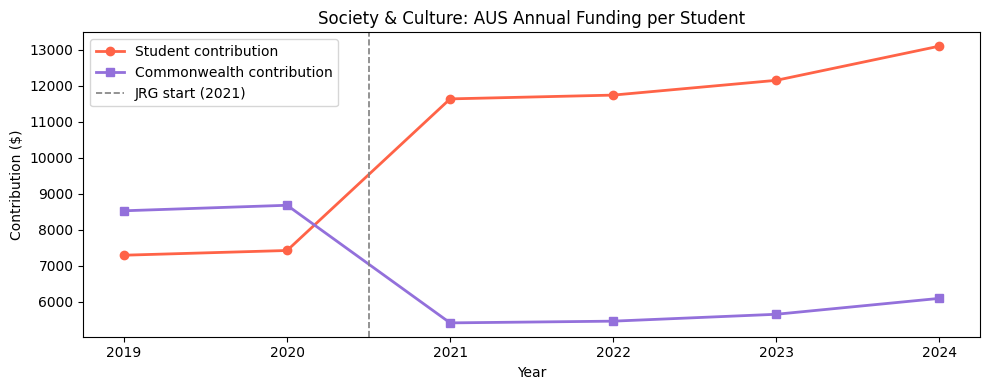


Student contribution: pre $7,364 -> post $12,157 (+65.1%)
Commonwealth:         pre $8,608 -> post $5,662 (-34.2%)


In [12]:
fund_raw  = pd.read_csv(FUND_PATH)
arch_fund = fund_raw[fund_raw['CategoryKey'] == 9].copy()
arch_fund_agg = (
    arch_fund[arch_fund['Year'] <= 2024]
    .groupby('Year')[['MaximumStudentContribution', 'CommonwealthContribution']]
    .mean()
    .round(0)
)
arch_fund_agg['total'] = arch_fund_agg['MaximumStudentContribution'] + arch_fund_agg['CommonwealthContribution']

print('=== Society & Culture: AUS Annual Funding per Student ===')
display(arch_fund_agg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(arch_fund_agg.index, arch_fund_agg['MaximumStudentContribution'],
        'o-', color='tomato', linewidth=2, label='Student contribution')
ax.plot(arch_fund_agg.index, arch_fund_agg['CommonwealthContribution'],
        's-', color='mediumpurple', linewidth=2, label='Commonwealth contribution')
ax.axvline(2020.5, linestyle='--', color='gray', linewidth=1.2, label='JRG start (2021)')
ax.set_title('Society & Culture: AUS Annual Funding per Student')
ax.set_xlabel('Year'); ax.set_ylabel('Contribution ($)'); ax.legend()
plt.tight_layout()
plt.show()

pre_stu  = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'MaximumStudentContribution'].mean()
post_stu = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'MaximumStudentContribution'].mean()
pre_cw   = arch_fund_agg.loc[arch_fund_agg.index <= 2020, 'CommonwealthContribution'].mean()
post_cw  = arch_fund_agg.loc[arch_fund_agg.index >= 2021, 'CommonwealthContribution'].mean()
print(f'\nStudent contribution: pre ${pre_stu:,.0f} -> post ${post_stu:,.0f} ({(post_stu/pre_stu-1)*100:+.1f}%)')
print(f'Commonwealth:         pre ${pre_cw:,.0f} -> post ${post_cw:,.0f} ({(post_cw/pre_cw-1)*100:+.1f}%)')


## Results Summary

### Model specification

$$\log(E_{ct}) = \beta_0 + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{DID}_{ct} + \sum_{t=2020}^{2024} \gamma_t \cdot \mathbf{1}_{[\text{year}=t]} + \varepsilon_{ct}$$

| Term | Variable | Definition |
|------|----------|------------|
| $\log(E_{ct})$ | Outcome | Log enrolments for country $c$ in year $t$ |
| $\beta_0$ | Intercept | UK baseline (2019) |
| $\beta_1 \cdot \text{Treated}_c$ | Country FE | $\text{Treated}_c = 1$ if AUS, $0$ if UK |
| $\text{Post}_t$ | --- | $= 1$ if $t \geq 2021$, else $0$ |
| $\text{DID}_{ct}$ | DiD term | $= \text{Treated}_c \times \text{Post}_t$ |
| $\beta_2$ | **JRG effect** | DiD estimate --- the coefficient of interest |
| $\gamma_t$ | Year FEs | Common time trend absorbed by year dummies (2020--2024) |
| $\varepsilon_{ct}$ | Error | HC3 heteroscedasticity-robust standard errors |

**Implemented in statsmodels as:**
```python
formula = "log_enrollments ~ treated + did + C(year)"
model   = smf.ols(formula, data=panel).fit(cov_type="HC3")
```

**Panel:** N = 12 (2 countries × 6 years, 2019--2024) | df = 4

| **Cell** | **Result** |
|----------|------------|
| **Main DiD** | $\hat{\beta} = -0.0319$, SE = 0.037, p = 0.389, 95% CI [$-$0.105, +0.041], approx. **−3.1%** relative to UK trend |
| **PanelOLS cross-check** | Estimates match exactly |
| **COVID sensitivity** | Full: −3.1% (p=0.389); dropping years produces degenerate SEs (2-country panel issue). Sign consistent (negative) across all variants |
| **Event study** | Pre-trend: +3.3% (2019). Post-JRG: +1.3% (2021), −3.0% (2022), −3.4% (2023), −1.0% (2024) |
| **Placebo** | fake\_post coef = −0.006, p = 0.854 --- no significant pre-trend break in AUS-only data |
| **Level spec** | $\hat{\beta} = -40{,}980$ students, p = 0.364, 95% CI [$-$129,477, +47,517] --- directionally consistent, not significant |

**Substantive finding:** Post-JRG, AUS S&C enrolments were approximately **−3.1% lower**
than the UK trend would predict ($\hat{\beta} = -0.0319$, p = 0.389, not significant, df = 4).
This is a null result --- no statistically detectable JRG effect on S&C enrolments at conventional
significance levels.

The event study reveals a nuanced pattern: 2021 showed a slight AUS outperformance (+1.3%),
likely reflecting a lagged COVID-rebound effect, followed by UK outperformance in 2022--2023
(−3.0%, −3.4%) before convergence in 2024 (−1.0%). The overall post-period average is
marginally negative but insignificant. The single pre-treatment point (+3.3% in 2019) suggests
AUS was growing slightly faster than UK before JRG, meaning the post-JRG negative gap is
slightly understated relative to a counterfactual with pre-existing AUS-favourable trend.

Society & Culture received the **largest student fee increase** of any discipline (+65.1%),
with Commonwealth funding falling 34.2%. Despite this strong discouragement signal, no
statistically significant reduction in AUS enrolments relative to the UK benchmark is detected.
This may reflect inelastic demand for S&C degrees (psychology, law, social sciences) or
compositional effects within the broad category masking heterogeneous sub-field responses.

The level specification (--40,980 students/year, p = 0.364) is directionally consistent with
the log-linear result and supports the null finding at conventional significance thresholds.

> **Data limitation:** UK panel restricted to 2019--2024 (N = 12, df = 4) due to irreconcilable
> JACS→CAH taxonomy break in 2019/20. Pre-2019 UK data at key = 9 contains only "04 Veterinary
> science" (~6--8K), a clear misassignment. Even reconstructing correct JACS subjects yields
> ~554--565K, leaving an irreconcilable ~167K gap vs post-2019 CAH totals (~731--788K) driven by
> Psychology having no JACS equivalent. Only 1 pre-treatment observation (2019) is available
> for the event study, preventing a formal parallel-trends test.
